In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import joblib
import sklearn
import seaborn as sns

In [2]:
df = pd.read_csv("datasets/winequality-red.csv", sep=";")
df.head(30)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
5,7.4,0.660,0.00,1.8,0.075,13.0,40.0,0.9978,3.51,0.56,9.4,5
6,7.9,0.600,0.06,1.6,0.069,15.0,59.0,0.9964,3.30,0.46,9.4,5
7,7.3,0.650,0.00,1.2,0.065,15.0,21.0,0.9946,3.39,0.47,10.0,7
8,7.8,0.580,0.02,2.0,0.073,9.0,18.0,0.9968,3.36,0.57,9.5,7
9,7.5,0.500,0.36,6.1,0.071,17.0,102.0,0.9978,3.35,0.80,10.5,5


In [3]:
print(df['quality'].value_counts().sort_index())

quality
3     10
4     53
5    681
6    638
7    199
8     18
Name: count, dtype: int64


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [5]:
df.duplicated().sum()

np.int64(240)

In [6]:
df.shape
df.describe().T

,count,mean,std,min,25%,50%,75%,max
fixed acidity,1599.0,8.319637,1.741096,4.60000,7.1000,7.90000,9.200000,15.90000
volatile acidity,1599.0,0.527821,0.179060,0.12000,0.3900,0.52000,0.640000,1.58000
citric acid,1599.0,0.270976,0.194801,0.00000,0.0900,0.26000,0.420000,1.00000
residual sugar,1599.0,2.538806,1.409928,0.90000,1.9000,2.20000,2.600000,15.50000
chlorides,1599.0,0.087467,0.047065,0.01200,0.0700,0.07900,0.090000,0.61100
free sulfur dioxide,1599.0,15.874922,10.460157,1.00000,7.0000,14.00000,21.000000,72.00000
total sulfur dioxide,1599.0,46.467792,32.895324,6.00000,22.0000,38.00000,62.000000,289.00000
density,1599.0,0.996747,0.001887,0.99007,0.9956,0.99675,0.997835,1.00369
pH,1599.0,3.311113,0.154386,2.74000,3.2100,3.31000,3.400000,4.01000
sulphates,1599.0,0.658149,0.169507,0.33000,0.5500,0.62000,0.730000,2.00000


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

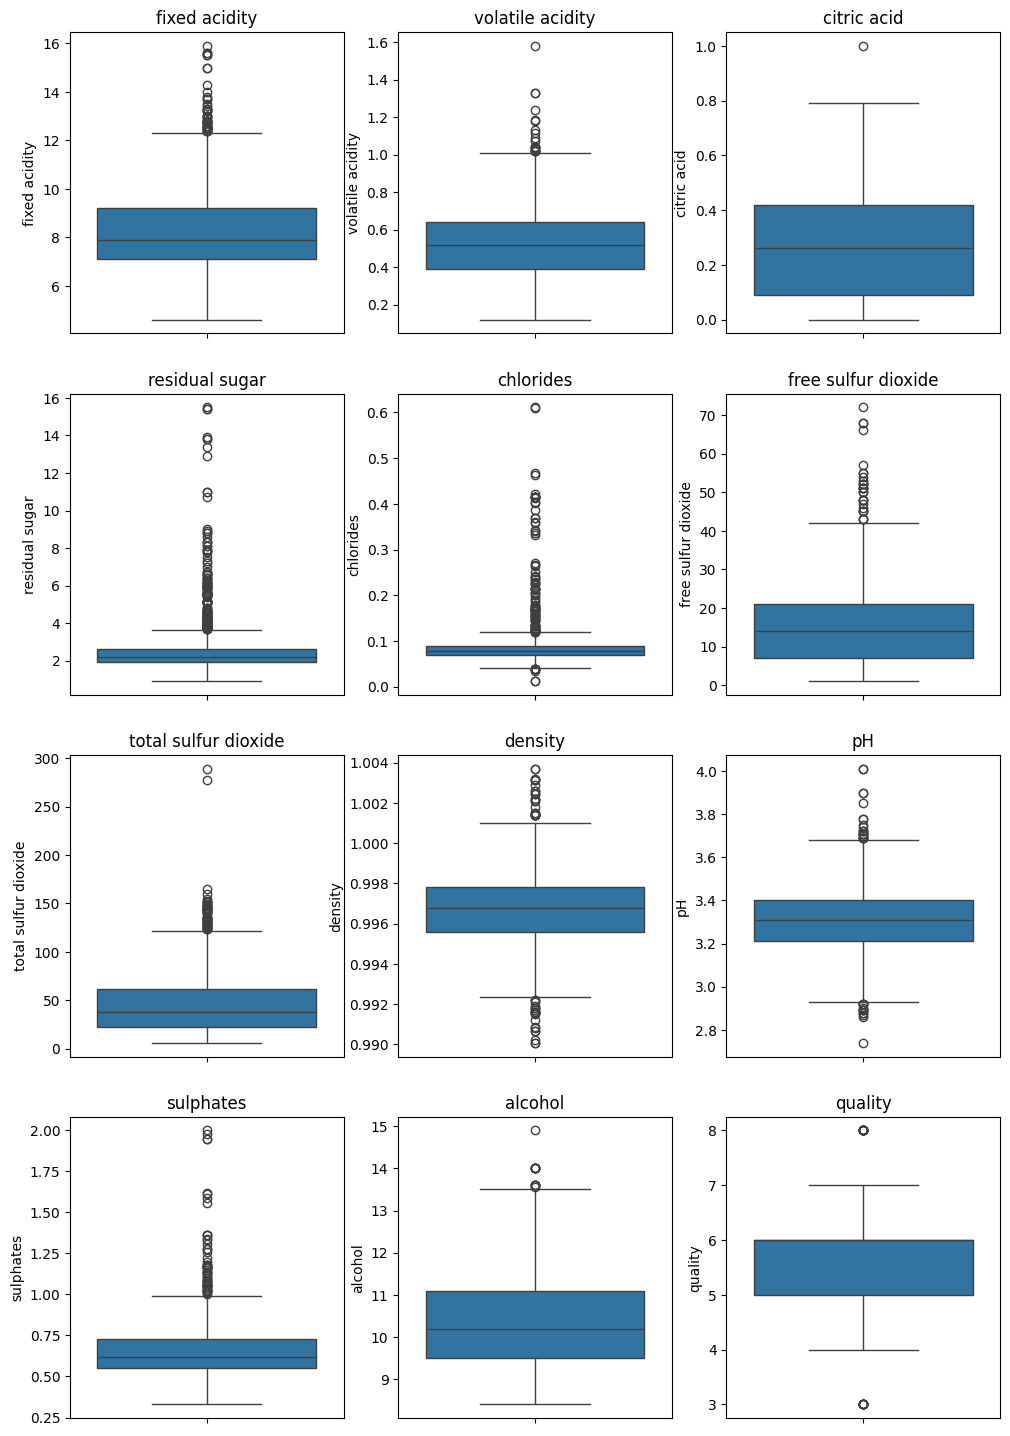

In [8]:
# Visualisation des valeurs abberrantes
def plot_boxplots (d):
    fig, axs= plt.subplots(4,3, figsize=(12,18))
    i = 0
    for var in d.columns:
        row = i//3
        col = i%3
        sns.boxplot(data=d[var], ax = axs[row, col])
        axs[row, col].set_title(var)
        i+=1
    plt.show()

plot_boxplots(df)

In [9]:
def processing_outliers (data):
    for var in data.columns:
        Q1, Q3= np.percentile(data[var], [25,75])
        IQR = Q3-Q1
        upper_bound = Q3 + (1.5 * IQR)
        lower_bound = Q1 - (1.5 * IQR)
        data.loc[data[var] < lower_bound, var] = lower_bound
        data.loc[data[var] > upper_bound, var] = upper_bound
    return data

dataframe = processing_outliers(df.drop(columns = "quality"))

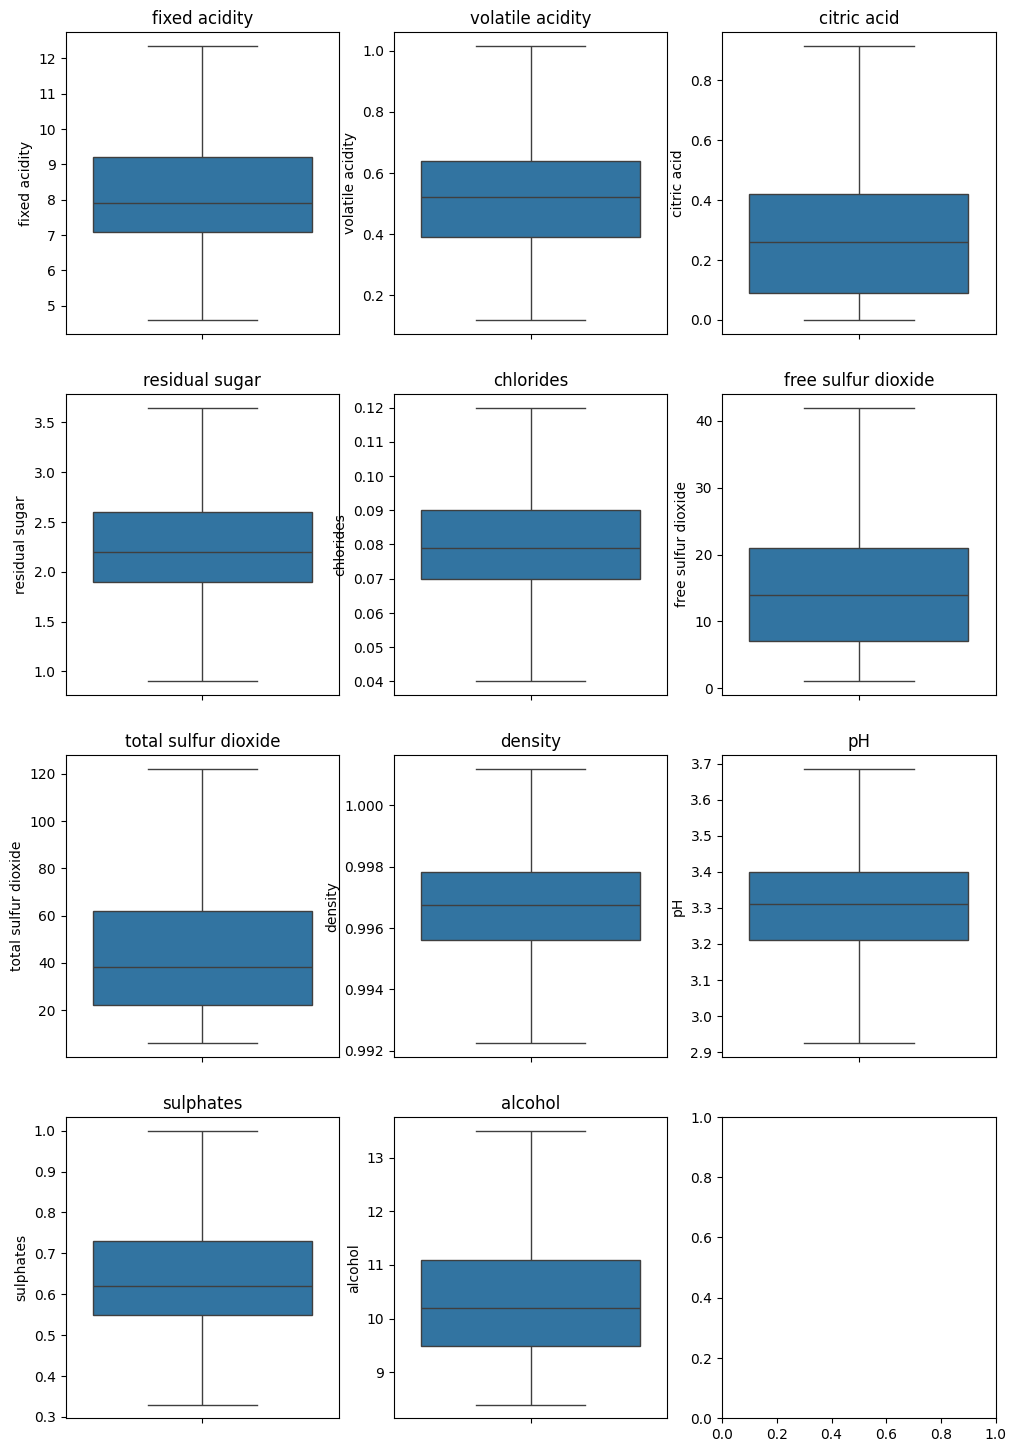

In [10]:
plot_boxplots(dataframe)

In [11]:
dataframe.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4


In [12]:
from sklearn.preprocessing import  MinMaxScaler

scaler = MinMaxScaler()
normalized_np= scaler.fit_transform(dataframe)
normalized_df= pd.DataFrame(normalized_np, columns=dataframe.columns, )
normalized_df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,0.476245,0.454111,0.296090,0.517221,0.514931,0.358273,0.342369,0.502795,0.507044,0.477360,0.396005
std,0.213659,0.194463,0.212692,0.221634,0.222780,0.239939,0.261845,0.202025,0.197173,0.204606,0.206825
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.322581,0.301676,0.098361,0.363636,0.375000,0.146341,0.137931,0.375000,0.375000,0.328358,0.215686
50%,0.425806,0.446927,0.284153,0.472727,0.487500,0.317073,0.275862,0.503635,0.506579,0.432836,0.352941
75%,0.593548,0.581006,0.459016,0.618182,0.625000,0.487805,0.482759,0.625000,0.625000,0.597015,0.529412
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [13]:
normalized_df["quality"] = df["quality"]
normalized_df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,0.361290,0.648045,0.000000,0.363636,0.4500,0.243902,0.241379,0.621085,0.769737,0.343284,0.196078,5
1,0.412903,0.849162,0.000000,0.618182,0.7250,0.585366,0.525862,0.509228,0.361842,0.522388,0.274510,5
2,0.412903,0.715084,0.043716,0.509091,0.6500,0.341463,0.413793,0.531600,0.440789,0.477612,0.274510,5
3,0.851613,0.178771,0.612022,0.363636,0.4375,0.390244,0.465517,0.643456,0.309211,0.373134,0.274510,6
4,0.361290,0.648045,0.000000,0.363636,0.4500,0.243902,0.241379,0.621085,0.769737,0.343284,0.196078,5


In [14]:
normalized_df.drop_duplicates(inplace = True)

# SMOTE (Synthetic Minority Over-sampling Technique)

## Qu'est-ce que SMOTE ?
SMOTE crée des **données synthétiques** pour les classes minoritaires (peu représentées). Au lieu de dupliquer les données existantes, elle génère de nouvelles données artificielles qui sont "entre" les points existants.

## Comment ça fonctionne ?
1. **Trouve les k-voisins les plus proches** de chaque point minoritaire
2. **Interpole** entre ces points pour créer de nouveaux points synthétiques
3. **Ajoute** ces nouveaux points au dataset

## Le paramètre `sampling_strategy='not majority'`
- Augmente toutes les classes minoritaires au même niveau que la classe majoritaire
- Utile pour les problèmes de **déséquilibre des données** (imbalanced dataset)

In [15]:
from imblearn.over_sampling import SMOTE


smote=SMOTE(sampling_strategy='not majority') 
x=normalized_df.drop(columns="quality", axis = 1)
y= normalized_df["quality"]
x,y=smote.fit_resample(x,y)
y.value_counts()

quality
5    576
6    576
7    576
4    576
8    576
3    576
Name: count, dtype: int64

In [16]:
# Separation des données en train, test

X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42)

In [17]:
#Create a new random Forest model with the best parameters
model = RandomForestClassifier(max_depth=15, min_samples_split=5, n_estimators = 1000)
model.fit(X_train, y_train)
print(accuracy_score(y_test, model.predict(X_test)))

0.8129218900675024


In [18]:
import joblib
joblib.dump(model, "random_forest_model.pkl")
joblib.dump(scaler, "scaler.pkl")

print("✅ Scaler et modèle sauvegardés avec succès.")

✅ Scaler et modèle sauvegardés avec succès.


In [19]:
# # Charger le modèle entraîné
# model = joblib.load("random_forest_model.pkl")

# # Charger le scaler
# scaler = joblib.load("scaler.pkl")

# # Préparer les nouvelles données (par exemple, une ligne du CSV)
# # Les 11 colonnes de features doivent être dans le même ordre que l'entraînement
# new_data = pd.DataFrame({
#     'fixed acidity': [7.4],
#     'volatile acidity': [0.7],
#     'citric acid': [0.0],
#     'residual sugar': [1.9],
#     'chlorides': [0.076],
#     'free sulfur dioxide': [11.0],
#     'total sulfur dioxide': [34.0],
#     'density': [0.9978],
#     'pH': [3.51],
#     'sulphates': [0.56],
#     'alcohol': [9.4]
# })

# # Normaliser les données (IMPORTANT!)
# new_data_normalized = pd.DataFrame(
#     scaler.transform(new_data),
#     columns=new_data.columns
# )

# # Faire une prédiction
# prediction = model.predict(new_data_normalized)
# print(f"Qualité prédite du vin: {prediction[0]}")

# # Obtenir la probabilité
# probabilities = model.predict_proba(new_data_normalized)
# print(f"Probabilités: {probabilities}")

In [20]:
# import joblib

# # Sauvegarder le scaler
# joblib.dump(scaler, "scaler.pkl")

# # Sauvegarder le modèle entraîné
# joblib.dump(model, "random_forest_model.pkl")

# print("✅ Modèle et scaler sauvegardés avec succès!")

In [21]:
# import pandas as pd
# import joblib

# # Charger les modèles
# model = joblib.load("random_forest_model.pkl")
# scaler = joblib.load("scaler.pkl")

# # Exemple: lire une ligne du CSV
# df = pd.read_csv("datasets/winequality-red.csv", sep=";")
# sample = df.drop(columns="quality").iloc[0:1]

# # Normaliser
# sample_normalized = pd.DataFrame(
#     scaler.transform(sample),
#     columns=sample.columns
# )

# # Prédire
# prediction = model.predict(sample_normalized)
# print(f"Qualité prédite: {prediction[0]}")

In [22]:
print(model.n_features_in_)

11


# Log  du model

*Entrainement simple* = 58% d'accuracy

*Entrainement avec normalisation, traitement des valeur abberrante*= 81% d'accuracy